In [2]:
from sklearn.cluster import KMeans

from src.load import DataLoader

In [3]:
dl = DataLoader()
videos = dl.channels().join(dl.videos(filtered=True), "channel_id").to_pandas()

In [4]:
videos.head()

,channel_uploader_id,channel_follower_count,channel_collected,channel_description,channel,channel_id,video_id,video_title,video_duration,video_views,video_likes,video_was_live,video_description,video_datetime_upload
0,@spdde,34500,2025-02-24 07:03:31,Wir machen soziale Politik für Dich. Abonniere...,SPD,UCSmbK1WtpYn2sOGLvSSXkKw,rLdkhkCxk6s,TikTok zeigt Kindern keine personalisierte Wer...,26,1703,57.0,False,TikTok zeigt Kindern keine personalisierte Wer...,2024-02-07 09:00:34
1,@spdde,34500,2025-02-24 07:03:31,Wir machen soziale Politik für Dich. Abonniere...,SPD,UCSmbK1WtpYn2sOGLvSSXkKw,R8NWwEg4cbs,Malu Dreyer beim Sonderparteitag der SPD,195,342,14.0,False,,2021-12-04 14:09:08
2,@spdde,34500,2025-02-24 07:03:31,Wir machen soziale Politik für Dich. Abonniere...,SPD,UCSmbK1WtpYn2sOGLvSSXkKw,2gV3Eh9ayUM,Saskia Esken bei Maybritt Illner zu Künstliche...,50,7109,80.0,False,Unsere Parteivorsitzende Saskia #Esken war zu ...,2023-04-14 13:34:46
3,@spdde,34500,2025-02-24 07:03:31,Wir machen soziale Politik für Dich. Abonniere...,SPD,UCSmbK1WtpYn2sOGLvSSXkKw,uBIYnBvUl5c,Wann gehst du am Sonntag wählen? 🗳️✍🏼,58,9459,241.0,False,"Am Sonntag hast so viel Macht, wie erst in 4 J...",2025-02-19 16:36:54
4,@spdde,34500,2025-02-24 07:03:31,Wir machen soziale Politik für Dich. Abonniere...,SPD,UCSmbK1WtpYn2sOGLvSSXkKw,DtDYKzp5s-0,Rede von Bundestagspräsidentin Bas bei der Wah...,1107,2390,58.0,False,Bundestagspräsidentin Bärbel Bas nutzte die Bu...,2022-02-13 14:33:14


In [5]:
classifier = KMeans(n_clusters=2)

videos["dur_cluster"] = classifier.fit_predict(videos[["video_duration"]])

<Axes: xlabel='log_video_duration', ylabel='log_video_views'>

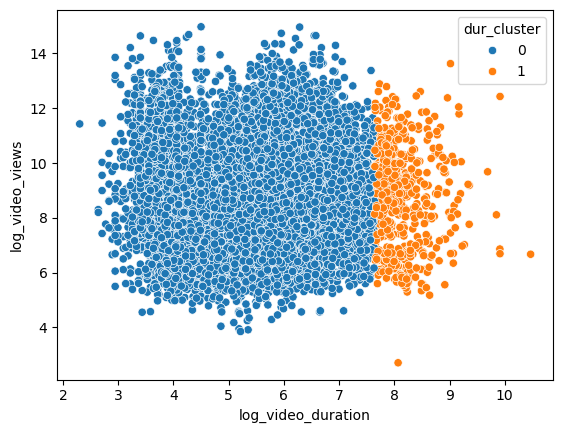

In [ ]:
import numpy as np
import seaborn as sns

videos["log_video_views"] = np.log(videos.video_views)
videos["elite"] = np.log(videos.video_views)
videos["log_video_duration"] = np.log(videos.video_duration)

sns.scatterplot(videos, x="log_video_duration", y="log_video_views", hue="dur_cluster")